Matriz inicial de feromônio:
[[0. 1. 1. 0. 0. 0.]
 [1. 0. 1. 1. 0. 0.]
 [1. 1. 0. 1. 1. 0.]
 [0. 1. 1. 0. 1. 1.]
 [0. 0. 1. 1. 0. 1.]
 [0. 0. 0. 1. 1. 0.]]

Vizinhos do nó 0: [1, 2]
Vizinhos do nó 2: [0, 1, 3, 4]

Exemplo de rotas encontradas:
Formiga 1: [0, 1, 2, 3, 4, 5]
Formiga 2: [0, 1, 2, 3, 4, 5]
Formiga 3: [0, 1, 2, 3, 4, 5]
Formiga 4: [0, 1, 2, 3, 4, 5]
Formiga 5: [0, 2, 1, 3, 4, 5]

       RESULTADO FINAL
Melhor rota encontrada: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0

Cálculo da melhor rota:
0 -> 1 = 2.0
1 -> 2 = 1.0
2 -> 3 = 2.0
3 -> 4 = 1.0
4 -> 5 = 2.0


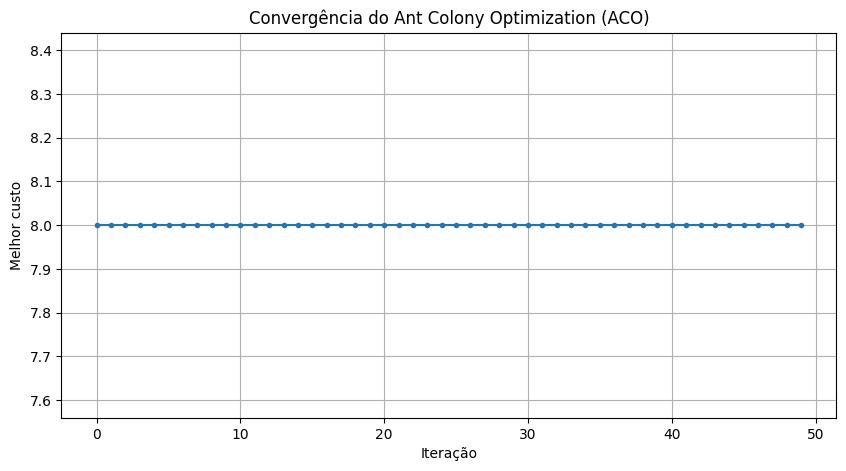


Matriz final de feromônio:
[[  0. 500.   0.   0.   0.   0.]
 [  0.   0. 500.   0.   0.   0.]
 [  0.   0.   0. 500.   0.   0.]
 [  0.   0.   0.   0. 500.   0.]
 [  0.   0.   0.   0.   0. 500.]
 [  0.   0.   0.   0.   0.   0.]]


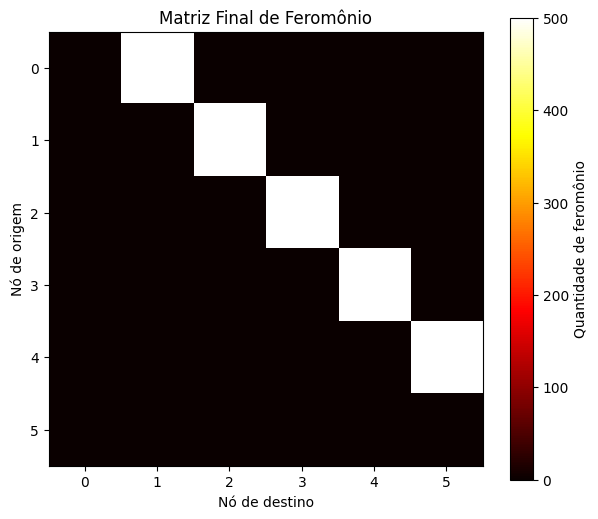

In [1]:
# ============================================
# LABORATÓRIO - ACO: OTIMIZAÇÃO POR COLÔNIA DE FORMIGAS
# ============================================

# 1. Importação das bibliotecas
import numpy as np
import random
import matplotlib.pyplot as plt

# Semente para obter sempre o mesmo resultado
np.random.seed(42)
random.seed(42)


# ============================================
# 2. REPRESENTAÇÃO DA REDE
# ============================================

CUSTOS = np.array([
    [0, 2, 4, np.inf, np.inf, np.inf],
    [2, 0, 1, 5, np.inf, np.inf],
    [4, 1, 0, 2, 3, np.inf],
    [np.inf, 5, 2, 0, 1, 4],
    [np.inf, np.inf, 3, 1, 0, 2],
    [np.inf, np.inf, np.inf, 4, 2, 0]
])

ORIGEM = 0
DESTINO = 5


# ============================================
# 3. PARÂMETROS DO ACO
# ============================================

NUM_FORMIGAS = 20
NUM_ITERACOES = 50

ALPHA = 1.0
BETA = 2.0

TAXA_EVAPORACAO = 0.5
Q = 100


# ============================================
# 4. MATRIZ INICIAL DE FEROMÔNIO
# ============================================

feromonio = np.ones_like(CUSTOS, dtype=float)

# Onde não existe ligação, não existe feromônio
feromonio[CUSTOS == np.inf] = 0

# Remove feromônio da diagonal principal
np.fill_diagonal(feromonio, 0)

print("Matriz inicial de feromônio:")
print(feromonio)


# ============================================
# 5. OBTENDO OS VIZINHOS
# ============================================

def obter_vizinhos(no):

    vizinhos = []

    for proximo in range(len(CUSTOS)):

        if proximo != no and CUSTOS[no][proximo] != np.inf:
            vizinhos.append(proximo)

    return vizinhos


print("\nVizinhos do nó 0:", obter_vizinhos(0))
print("Vizinhos do nó 2:", obter_vizinhos(2))


# ============================================
# 6. ESCOLHENDO O PRÓXIMO NÓ
# ============================================

def escolher_proximo(no_atual, visitados):

    vizinhos = obter_vizinhos(no_atual)

    # Não pode voltar para um nó já visitado
    candidatos = [
        no for no in vizinhos
        if no not in visitados
    ]

    if not candidatos:
        return None

    atratividades = []

    for proximo in candidatos:

        fer = feromonio[no_atual][proximo]
        custo = CUSTOS[no_atual][proximo]

        atratividade = (
            (fer ** ALPHA)
            * ((1 / custo) ** BETA)
        )

        atratividades.append(atratividade)

    soma = sum(atratividades)

    # Segurança caso a soma seja zero
    if soma == 0:
        return random.choice(candidatos)

    probabilidades = [
        valor / soma
        for valor in atratividades
    ]

    return random.choices(
        candidatos,
        weights=probabilidades,
        k=1
    )[0]


# ============================================
# 7. CONSTRUINDO UMA ROTA
# ============================================

def construir_rota():

    rota = [ORIGEM]
    atual = ORIGEM

    while atual != DESTINO:

        proximo = escolher_proximo(
            atual,
            rota
        )

        if proximo is None:
            return None

        rota.append(proximo)
        atual = proximo

    return rota


print("\nExemplo de rotas encontradas:")

for i in range(5):

    rota = construir_rota()

    print(f"Formiga {i + 1}: {rota}")


# ============================================
# 8. CALCULANDO O CUSTO DA ROTA
# ============================================

def calcular_custo(rota):

    total = 0

    for i in range(len(rota) - 1):

        origem = rota[i]
        destino = rota[i + 1]

        total += CUSTOS[origem][destino]

    return total


# ============================================
# 9. DEPÓSITO DE FEROMÔNIO
# ============================================

def depositar_feromonio(rota, custo):

    # Quanto menor o custo, maior o depósito
    deposito = Q / custo

    for i in range(len(rota) - 1):

        origem = rota[i]
        destino = rota[i + 1]

        feromonio[origem][destino] += deposito


# ============================================
# 10. EVAPORAÇÃO DO FEROMÔNIO
# ============================================

def evaporar_feromonio():

    global feromonio

    feromonio *= (1 - TAXA_EVAPORACAO)

    # Mantém zero onde não existe conexão
    feromonio[CUSTOS == np.inf] = 0

    # Mantém a diagonal igual a zero
    np.fill_diagonal(feromonio, 0)


# ============================================
# 11. EXECUTANDO O ACO
# ============================================

melhor_rota = None
melhor_custo = float("inf")

historico = []

for iteracao in range(NUM_ITERACOES):

    rotas = []

    # Cada formiga procura uma rota
    for _ in range(NUM_FORMIGAS):

        rota = construir_rota()

        if rota is not None:

            custo = calcular_custo(rota)

            rotas.append((rota, custo))

            # Verifica se encontrou uma solução melhor
            if custo < melhor_custo:

                melhor_custo = custo
                melhor_rota = rota.copy()

    # Evaporação
    evaporar_feromonio()

    # Depósito de feromônio
    for rota, custo in rotas:

        depositar_feromonio(
            rota,
            custo
        )

    # Guarda a evolução
    historico.append(melhor_custo)


# ============================================
# 12. RESULTADO
# ============================================

print("\n==============================")
print("       RESULTADO FINAL")
print("==============================")

print("Melhor rota encontrada:", melhor_rota)
print("Melhor custo:", melhor_custo)


# Mostrar o cálculo do custo
print("\nCálculo da melhor rota:")

for i in range(len(melhor_rota) - 1):

    origem = melhor_rota[i]
    destino = melhor_rota[i + 1]

    print(
        f"{origem} -> {destino} = "
        f"{CUSTOS[origem][destino]}"
    )


# ============================================
# 13. GRÁFICO DE CONVERGÊNCIA
# ============================================

plt.figure(figsize=(10, 5))

plt.plot(
    historico,
    marker="o",
    markersize=3
)

plt.xlabel("Iteração")
plt.ylabel("Melhor custo")

plt.title(
    "Convergência do Ant Colony Optimization (ACO)"
)

plt.grid()

plt.show()


# ============================================
# 14. MATRIZ FINAL DE FEROMÔNIO
# ============================================

print("\nMatriz final de feromônio:")
print(np.round(feromonio, 2))


plt.figure(figsize=(7, 6))

plt.imshow(
    feromonio,
    cmap="hot"
)

plt.colorbar(
    label="Quantidade de feromônio"
)

plt.xlabel("Nó de destino")
plt.ylabel("Nó de origem")

plt.title(
    "Matriz Final de Feromônio"
)

plt.xticks(range(len(CUSTOS)))
plt.yticks(range(len(CUSTOS)))

plt.show()